##### Copyright 2018 The TF-Agents Authors.

##### Some enhancements and added info was added by guyk1971

### Get Started
<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/agents/blob/master/tf_agents/colabs/6_reinforce_tutorial.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/agents/blob/master/tf_agents/colabs/6_reinforce_tutorial.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>


In [1]:
# Note: If you haven't installed the following dependencies, run:
# !apt-get install -y xvfb
# !pip install 'gym==0.10.11'
# !pip install 'imageio==2.4.0'
# !pip install PILLOW
# !pip install 'pyglet==1.3.2'
# !pip install pyvirtualdisplay
# !pip install tf-agents-nightly
try:
    %%tensorflow_version 2.x
except:
    pass

import os
import sys
print('inserting the following to path',os.path.abspath('../..'))
sys.path.insert(0,os.path.abspath('../..'))
print(sys.path)

inserting the following to path /home/guy/workspace/study/git/agents
['/home/guy/workspace/study/git/agents', '/home/guy/anaconda3/envs/rltf20/lib/python36.zip', '/home/guy/anaconda3/envs/rltf20/lib/python3.6', '/home/guy/anaconda3/envs/rltf20/lib/python3.6/lib-dynload', '', '/home/guy/.local/lib/python3.6/site-packages', '/home/guy/anaconda3/envs/rltf20/lib/python3.6/site-packages', '/home/guy/anaconda3/envs/rltf20/lib/python3.6/site-packages/IPython/extensions', '/home/guy/.ipython']


## Introduction

This example shows how to train a [REINFORCE](http://www-anw.cs.umass.edu/~barto/courses/cs687/williams92simple.pdf) agent on the Cartpole environment using the TF-Agents library, similar to the [DQN tutorial](1_dqn_tutorial.ipynb).

![Cartpole environment](images/cartpole.png)

We will walk you through all the components in a Reinforcement Learning (RL) pipeline for training, evaluation and data collection.


## Setup

In [2]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import base64
import imageio
import IPython
import matplotlib
import matplotlib.pyplot as plt
import PIL.Image
# import pyvirtualdisplay

import tensorflow as tf

from tf_agents.agents.reinforce import reinforce_agent
from tf_agents.drivers import dynamic_step_driver
from tf_agents.environments import suite_gym
from tf_agents.environments import tf_py_environment
from tf_agents.eval import metric_utils
from tf_agents.metrics import tf_metrics
from tf_agents.networks import actor_distribution_network
from tf_agents.replay_buffers import tf_uniform_replay_buffer
from tf_agents.trajectories import trajectory
from tf_agents.utils import common

# my import to control gpu usage
from tf_agents.utils.my_utils import set_gpu_device


tf.compat.v1.enable_v2_behavior()
set_gpu_device('0')


# Set up a virtual display for rendering OpenAI gym environments.
# display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()

1 Physical GPUs, 1 Logical GPU


## Hyperparameters

In [3]:
env_name = "CartPole-v0" # @param {type:"string"}
num_iterations = 250 # @param {type:"integer"}
collect_episodes_per_iteration = 2 # @param {type:"integer"}
replay_buffer_capacity = 2000 # @param {type:"integer"}

fc_layer_params = (100,)

learning_rate = 1e-3 # @param {type:"number"}
log_interval = 25 # @param {type:"integer"}
num_eval_episodes = 10 # @param {type:"integer"}
eval_interval = 50 # @param {type:"integer"}

## Environment

Environments in RL represent the task or problem that we are trying to solve. Standard environments can be easily created in TF-Agents using `suites`. We have different `suites` for loading environments from sources such as the OpenAI Gym, Atari, DM Control, etc., given a string environment name.

Now let us load the CartPole environment from the OpenAI Gym suite.

In [4]:
env = suite_gym.load(env_name)

We can render this environment to see how it looks. A free-swinging pole is attached to a cart.  The goal is to move the cart right or left in order to keep the pole pointing up.

In [5]:
#@test {"skip": true}
env.reset()
# PIL.Image.fromarray(env.render())

TimeStep(step_type=array(0, dtype=int32), reward=array(0., dtype=float32), discount=array(1., dtype=float32), observation=array([ 0.02620988, -0.03770974, -0.0247835 , -0.00382777], dtype=float32))

The `time_step = environment.step(action)` statement takes `action` in the environment.  The `TimeStep` tuple returned contains the environment's next observation and reward for that action. The `time_step_spec()` and `action_spec()` methods in the environment return the specifications (types, shapes, bounds) of the `time_step` and `action` respectively.

In [6]:
print('Observation Spec:')
print(env.time_step_spec().observation)
print('Action Spec:')
print(env.action_spec())

Observation Spec:
BoundedArraySpec(shape=(4,), dtype=dtype('float32'), name='observation', minimum=[-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], maximum=[4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38])
Action Spec:
BoundedArraySpec(shape=(), dtype=dtype('int64'), name='action', minimum=0, maximum=1)


So, we see that observation is an array of 4 floats: the position and velocity of the cart, and the angular position and velocity of the pole. Since only two actions are possible (move left or move right), the `action_spec` is a scalar where 0 means "move left" and 1 means "move right."

In [7]:
time_step = env.reset()
print('Time step:')
print(time_step)

action = 1

next_time_step = env.step(action)
print('Next time step:')
print(next_time_step)

Time step:
TimeStep(step_type=array(0, dtype=int32), reward=array(0., dtype=float32), discount=array(1., dtype=float32), observation=array([-0.03180533,  0.02100484,  0.04731834, -0.02905179], dtype=float32))
Next time step:
TimeStep(step_type=array(1, dtype=int32), reward=array(1., dtype=float32), discount=array(1., dtype=float32), observation=array([-0.03138523,  0.2154174 ,  0.04673731, -0.30643782], dtype=float32))


Usually we create two environments: one for training and one for evaluation. Most environments are written in pure python, but they can be easily converted to TensorFlow using the `TFPyEnvironment` wrapper. The original environment's API uses numpy arrays, the `TFPyEnvironment` converts these to/from `Tensors` for you to more easily interact with TensorFlow policies and agents.


In [8]:
train_py_env = suite_gym.load(env_name)
eval_py_env = suite_gym.load(env_name)

train_env = tf_py_environment.TFPyEnvironment(train_py_env)
eval_env = tf_py_environment.TFPyEnvironment(eval_py_env)

## Agent

The algorithm that we use to solve an RL problem is represented as an `Agent`. In addition to the REINFORCE agent, TF-Agents provides standard implementations of a variety of `Agents` such as [DQN](https://storage.googleapis.com/deepmind-media/dqn/DQNNaturePaper.pdf), [DDPG](https://arxiv.org/pdf/1509.02971.pdf), [TD3](https://arxiv.org/pdf/1802.09477.pdf), [PPO](https://arxiv.org/abs/1707.06347) and [SAC](https://arxiv.org/abs/1801.01290).

To create a REINFORCE Agent, we first need an `Actor Network` that can learn to predict the action given an observation from the environment.

We can easily create an `Actor Network` using the specs of the observations and actions. We can specify the layers in the network which, in this example, is the `fc_layer_params` argument set to a tuple of `ints` representing the sizes of each hidden layer (see the Hyperparameters section above).



In [11]:
actor_net = actor_distribution_network.ActorDistributionNetwork(
    train_env.observation_spec(),
    train_env.action_spec(),
    fc_layer_params=fc_layer_params)

<font color = 'blue'>
Note: 
in the cell above we define the model that will get an observation (state) and will predict the best next action. The actor_distribution_network implies that its a neural net based model. 
we might want to add any other model we can think of. for example, in garage they have implemented a linear regression model. we can add it here as an exercise.    
</font>

We also need an `optimizer` to train the network we just created, and a `train_step_counter` variable to keep track of how many times the network was updated.





In [12]:
optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate=learning_rate)

train_step_counter = tf.compat.v2.Variable(0)

tf_agent = reinforce_agent.ReinforceAgent(
    train_env.time_step_spec(),
    train_env.action_spec(),
    actor_network=actor_net,
    optimizer=optimizer,
    normalize_returns=True,
    train_step_counter=train_step_counter)
tf_agent.initialize()

## Policies

In TF-Agents, policies represent the standard notion of policies in RL: given a `time_step` produce an action or a distribution over actions. The main method is `policy_step = policy.step(time_step)` where `policy_step` is a named tuple `PolicyStep(action, state, info)`.  The `policy_step.action` is the `action` to be applied to the environment, `state` represents the state for stateful (RNN) policies and `info` may contain auxiliary information such as log probabilities of the actions.

Agents contain two policies: the main policy that is used for evaluation/deployment (agent.policy) and another policy that is used for data collection (agent.collect_policy).  
<font color='blue'> Note: the collect_policy is what we know as "behavior policy" from the lectures, right ? and the agent.policy is the target policy that we strive to learn. in 'on-policy' algorithms, they should be identical </font>

In [15]:
eval_policy = tf_agent.policy
collect_policy = tf_agent.collect_policy

In [16]:
print(eval_policy)
print(collect_policy)

<font color='blue'> Note that we send the agent the model that predicts the action and actually implement the policy. upon the output of the model we can apply a policy. for example, if we choose GreedyPolicy, if its deterministic, it will take the mode of the robability distribution. if its stochastic - how does it work with Greedy ???
In CS294 Homework we used deterministic policy for evaluation so I guess also here the greedy is detrministic so if we havecategorical distribution it will simply take the argmax of the logits (and not sample according to the logits) </font>
    

## Metrics and Evaluation

The most common metric used to evaluate a policy is the average return. The return is the sum of rewards obtained while running a policy in an environment for an episode, and we usually average this over a few episodes. We can compute the average return metric as follows.


In [17]:
#@test {"skip": true}
def compute_avg_return(environment, policy, num_episodes=10):
    total_return = 0.0
    for _ in range(num_episodes):

        time_step = environment.reset()
        episode_return = 0.0

        while not time_step.is_last():
            action_step = policy.action(time_step)
            time_step = environment.step(action_step.action)
            episode_return += time_step.reward   
        total_return += episode_return

    avg_return = total_return / num_episodes      
    return avg_return.numpy()[0]

# Please also see the metrics module for standard implementations of different
# metrics.

## Replay Buffer

In order to keep track of the data collected from the environment, we will use the TFUniformReplayBuffer. This replay buffer is constructed using specs describing the tensors that are to be stored, which can be obtained from the agent using `tf_agent.collect_data_spec`.

In [19]:
replay_buffer = tf_uniform_replay_buffer.TFUniformReplayBuffer(
    data_spec=tf_agent.collect_data_spec,
    batch_size=train_env.batch_size,
    max_length=replay_buffer_capacity)

For most agents, the `collect_data_spec` is a `Trajectory` named tuple containing the observation, action, reward etc.

## Data Collection

As REINFORCE learns from whole episodes, we define a function to collect an episode using the given data collection policy and save the data (observations, actions, rewards etc.) as trajectories in the replay buffer.

In [20]:
#@test {"skip": true}

def collect_episode(environment, policy, num_episodes):

    episode_counter = 0
    environment.reset()

    while episode_counter < num_episodes:
        time_step = environment.current_time_step()
        action_step = policy.action(time_step)
        next_time_step = environment.step(action_step.action)
        traj = trajectory.from_transition(time_step, action_step, next_time_step)

        # Add trajectory to the replay buffer
        replay_buffer.add_batch(traj)

        if traj.is_boundary():
            episode_counter += 1


# This loop is so common in RL, that we provide standard implementations of
# these. For more details see the drivers module.

<font color='red'> **Exercise**: replace the above with a driver </font>

In [ ]:
# a preliminary answer (not yet final)
collect_driver = dynamic_episode_driver.DynamicStepDriver(
        train_env,
        tf_agent.collect_policy,
        observers=[replay_buffer.add_batch],
        num_episodes=initial_collect_steps)  

# now we can use it in the training loop. instead of calling collect_episode we can use collect_driver.run()

## Training the agent

The training loop involves both collecting data from the environment and optimizing the agent's networks. Along the way, we will occasionally evaluate the agent's policy to see how we are doing.

The following will take ~3 minutes to run.

In [21]:
#@test {"skip": true}
try:
    %%time
except:
    pass

# (Optional) Optimize by wrapping some of the code in a graph using TF function.
tf_agent.train = common.function(tf_agent.train)

# Reset the train step
tf_agent.train_step_counter.assign(0)

# Evaluate the agent's policy once before training.
avg_return = compute_avg_return(eval_env, tf_agent.policy, num_eval_episodes)
returns = [avg_return]

for _ in range(num_iterations):

    # Collect a few episodes using collect_policy and save to the replay buffer.
    collect_episode(train_env, tf_agent.collect_policy, collect_episodes_per_iteration)

    # Use data from the buffer and update the agent's network.
    experience = replay_buffer.gather_all()
    train_loss = tf_agent.train(experience)
    replay_buffer.clear()

    step = tf_agent.train_step_counter.numpy()

    if step % log_interval == 0:
        print('step = {0}: loss = {1}'.format(step, train_loss.loss))

    if step % eval_interval == 0:
        avg_return = compute_avg_return(eval_env, tf_agent.policy, num_eval_episodes)
        print('step = {0}: Average Return = {1}'.format(step, avg_return))
        returns.append(avg_return)

step = 25: loss = -0.15041518211364746
step = 50: loss = -0.3754723072052002
step = 50: Average Return = 55.20000076293945
step = 75: loss = -0.15585851669311523
step = 100: loss = 0.036620140075683594
step = 100: Average Return = 145.3000030517578
step = 125: loss = -1.0667104721069336
step = 150: loss = -1.311091423034668
step = 150: Average Return = 196.89999389648438
step = 175: loss = 0.12836456298828125
step = 200: loss = 2.2714455127716064
step = 200: Average Return = 200.0
step = 225: loss = -2.8804683685302734
step = 250: loss = 2.576931953430176
step = 250: Average Return = 200.0


## Visualization



### Plots

We can plot return vs global steps to see the performance of our agent. In `Cartpole-v0`, the environment gives a reward of +1 for every time step the pole stays up, and since the maximum number of steps is 200, the maximum possible return is also 200.

(0.08000040054321289, 250)

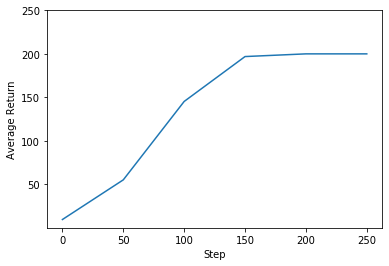

In [22]:
#@test {"skip": true}

steps = range(0, num_iterations + 1, eval_interval)
plt.plot(steps, returns)
plt.ylabel('Average Return')
plt.xlabel('Step')
plt.ylim(top=250)

### Videos

It is helpful to visualize the performance of an agent by rendering the environment at each step. Before we do that, let us first create a function to embed videos in this colab.

In [ ]:
def embed_mp4(filename):
  """Embeds an mp4 file in the notebook."""
  video = open(filename,'rb').read()
  b64 = base64.b64encode(video)
  tag = '''
  <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
  Your browser does not support the video tag.
  </video>'''.format(b64.decode())

  return IPython.display.HTML(tag)

The following code visualizes the agent's policy for a few episodes:

In [ ]:
num_episodes = 3
video_filename = 'imageio.mp4'
with imageio.get_writer(video_filename, fps=60) as video:
  for _ in range(num_episodes):
    time_step = eval_env.reset()
    video.append_data(eval_py_env.render())
    while not time_step.is_last():
      action_step = tf_agent.policy.action(time_step)
      time_step = eval_env.step(action_step.action)
      video.append_data(eval_py_env.render())

embed_mp4(video_filename)